Linear Regression

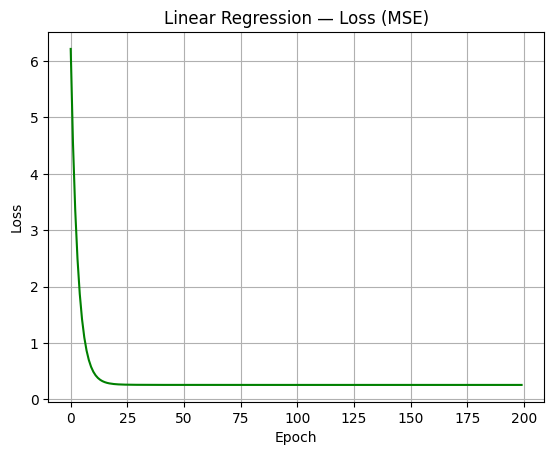

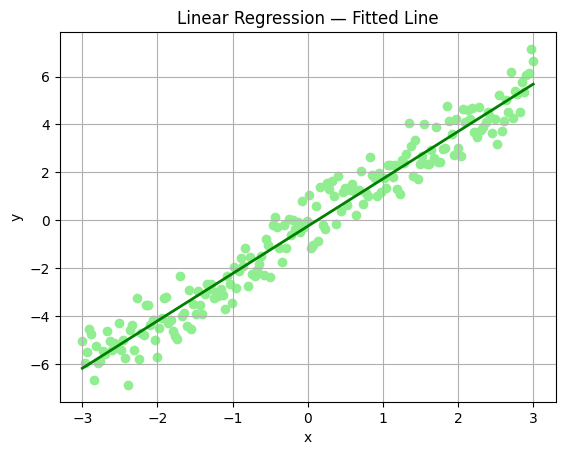

In [1]:
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(0)

n = 200
X = np.linspace(-3, 3, n).reshape(-1, 1)
y = 2 * X.ravel() - 0.3 + 0.7 * np.random.randn(n)

w, b = 0.0, 0.0
lr = 0.05
epochs = 200
losses = []

for _ in range(epochs):
    preds = w * X.ravel() + b
    err = preds - y
    loss = (err**2).mean() / 2
    losses.append(loss)
    dw = (X.ravel() * err).mean()
    db = err.mean()
    w -= lr * dw
    b -= lr * db

plt.figure()
plt.plot(losses, color="green")
plt.title("Linear Regression — Loss (MSE)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

plt.figure()
plt.scatter(X, y, color="lightgreen")
idx = np.argsort(X.ravel())
plt.plot(X[idx], (w * X + b)[idx], color="green", linewidth=2)
plt.title("Linear Regression — Fitted Line")
plt.xlabel("x")
plt.ylabel("y")
plt.grid(True)
plt.show()

Logistic Regression

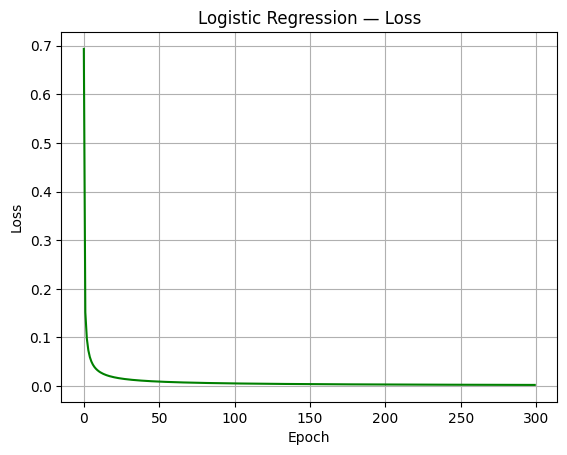

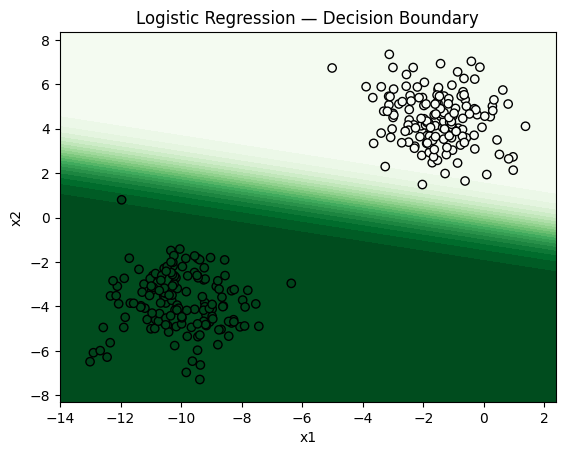

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
np.random.seed(1)

X, y = make_blobs(n_samples=300, centers=2, cluster_std=1.2)
w = np.zeros(X.shape[1])
b = 0.0
lr = 0.2
losses = []

def sigmoid(z): return 1 / (1 + np.exp(-z))

for _ in range(300):
    z = X.dot(w) + b
    p = sigmoid(z)
    loss = -(y * np.log(p + 1e-12) + (1 - y) * np.log(1 - p + 1e-12)).mean()
    losses.append(loss)
    dw = X.T.dot(p - y) / len(X)
    db = (p - y).mean()
    w -= lr * dw
    b -= lr * db

plt.figure()
plt.plot(losses, color="green")
plt.title("Logistic Regression — Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

xx, yy = np.meshgrid(
    np.linspace(X[:, 0].min() - 1, X[:, 0].max() + 1, 200),
    np.linspace(X[:, 1].min() - 1, X[:, 1].max() + 1, 200)
)
grid = np.c_[xx.ravel(), yy.ravel()]
probs = sigmoid(grid.dot(w) + b).reshape(xx.shape)

plt.figure()
plt.contourf(xx, yy, probs, 20, cmap="Greens")
plt.scatter(X[:, 0], X[:, 1], c=y, cmap="Greens", edgecolor="black")
plt.title("Logistic Regression — Decision Boundary")
plt.xlabel("x1")
plt.ylabel("x2")
plt.show()

Softmax Regression

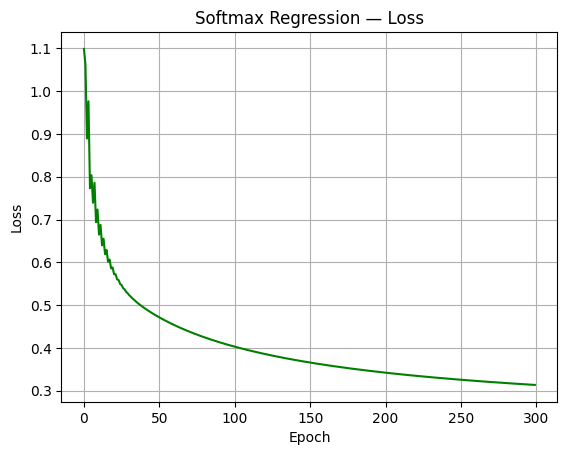

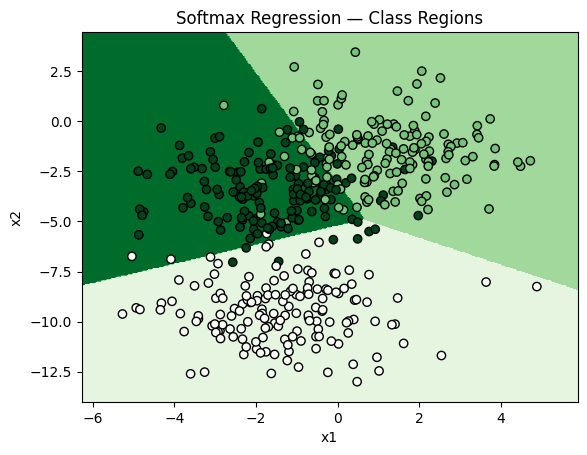

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
np.random.seed(2)

X, y = make_blobs(n_samples=450, centers=3, cluster_std=1.5)
K = 3

W = np.zeros((X.shape[1], K))
b = np.zeros(K)
lr = 0.2
epochs = 300
losses = []

def softmax(z):
    z -= z.max(axis=1, keepdims=True)
    expz = np.exp(z)
    return expz / expz.sum(axis=1, keepdims=True)

for _ in range(epochs):
    logits = X.dot(W)+b
    probs = softmax(logits)
    Y = np.zeros_like(probs); Y[np.arange(len(y)), y] = 1
    loss = -np.sum(Y*np.log(probs+1e-12))/len(X)
    losses.append(loss)
    dW = X.T.dot(probs-Y)/len(X)
    db = (probs-Y).mean(axis=0)
    W -= lr*dW
    b -= lr*db

plt.figure()
plt.plot(losses, color="green")
plt.title("Softmax Regression — Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

xx, yy = np.meshgrid(
    np.linspace(X[:,0].min()-1, X[:,0].max()+1, 300),
    np.linspace(X[:,1].min()-1, X[:,1].max()+1, 300)
)
grid = np.c_[xx.ravel(), yy.ravel()]
preds = np.argmax(softmax(grid.dot(W)+b), axis=1).reshape(xx.shape)

plt.figure()
plt.contourf(xx, yy, preds, K, cmap="Greens")
plt.scatter(X[:,0], X[:,1], c=y, cmap="Greens", edgecolor="black")
plt.title("Softmax Regression — Class Regions")
plt.xlabel("x1")
plt.ylabel("x2")
plt.show()